## Author: Saad Abdullah



### Installing Required Packages

### Importing The Packages

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image

In [ ]:
!pip install requests
!pip install beautifulsoup4
!pip install pandas

### Scraping the Recipe URLs
So, Instead of nesting the scraping part, I choose to first scrap the URLs of recipies from index and then scrap each recipe Individually.

In [4]:
# Function to check if the post is a valid recipe based on the presence of specific div
def is_valid_recipe(post):
    if post.find('div', class_='wprm-ww-points'):
        return True
    return False

# Function to scrape a single page of recipes
def scrape_recipe_page(page_number):
    url = f'https://www.skinnytaste.com/recipe-index/?_paged={page_number}'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    posts = soup.find_all('article', class_=lambda value: value and "post type-post status-publish has-post-thumbnail" in value)

    recipes = []
    articles = []
    for post in posts:
        if is_valid_recipe(post):
            title_tag = post.find('h2', class_='entry-title')
            if title_tag:
                recipe_name = title_tag.get_text(strip=True)
                recipe_url = title_tag.find('a')['href']
                # Scrape the image URL from the thumbnail div, did this because scraping images here was more robust approach to me.
                image_div = post.find('div', class_='post-thumb-img-content post-thumb')
                image_url = image_div.find('img')['src'] if image_div and image_div.find('img') else None
                recipes.append({'Recipe Name': recipe_name, 'Recipe URL': recipe_url, 'Image URL': image_url})
        else:
          # did this only for testing, to check if my filteration of recipies and articles based on WW points is working or not.
          title_tag = post.find('h2', class_='entry-title')
          if title_tag:
              recipe_name = title_tag.get_text(strip=True)
              recipe_url = title_tag.find('a')['href']
              articles.append({'Article Name': recipe_name, 'Article URL': recipe_url})

    return recipes, articles

# Function to scrape multiple pages (e.g., 50 pages)
def scrape_multiple_pages(total_pages):
    all_recipes = []
    all_articles = []

    for page in range(1, total_pages + 1):
        print(f"Scraping page {page}...")
        recipes, articles = scrape_recipe_page(page)
        all_recipes.extend(recipes)
        all_articles.extend(articles)

    return all_recipes, all_articles


total_pages = 50
recepies, articles = scrape_multiple_pages(total_pages)

# Store the recipe URLs in a CSV file
df = pd.DataFrame(recepies)
df.to_csv('/content/recipe_urls.csv', index=False)

# Store the article URLs in a CSV file
# stored to just check if the cleaning logic was working fine or not.
df = pd.DataFrame(articles)
df.to_csv('/content/article_urls.csv', index=False)

print(f"Scraping complete. {len(recepies)} valid recipes found.")
print(f"Scraping complete. {len(articles)} valid articles found.")

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...
Scraping 

### Scrapping Individual Recipies Now.

In [5]:
# Function to scrape data from a single recipe page
def scrape_recipe_details(recipe_url, image_url):
    response = requests.get(recipe_url)

    soup = BeautifulSoup(response.text, 'html.parser')

    recipe_name = soup.find('h1', class_='entry-title').get_text(strip=True)
    calories_tag = soup.find('span', class_='recipe-meta-value value-calories')
    personal_points = soup.find('span', class_='recipe-meta-value recipe-ww-pp icon')

    if calories_tag:
        calories = calories_tag.get_text(strip=True).replace('Cals:', '').strip()
    else:
        calories = None

    if personal_points:
        points = personal_points.get_text(strip=True)
    else:
        points = None

    recipe_keys = []
    ul_tag = soup.find('ul', class_='cat-icons post-icons')
    if ul_tag:
        li_tags = ul_tag.find_all('li')
        # loop becuase a recipe can have multiple keys.
        for li in li_tags:
            key = li.get_text(strip=True)
            recipe_keys.append(key)

    recipe_keys_str = ', '.join(recipe_keys) if recipe_keys else None

    summary_tag = soup.find('div', class_='entry-content clear').find('p')
    if summary_tag:
        recipe_summary = summary_tag.get_text(strip=True)
    else:
        recipe_summary = None

    return {
        'Recipe Name': recipe_name,
        'Image URL': image_url,
        'Calories': calories,
        'Recipe Keys': recipe_keys_str,
        'Personal Points': points,
        'Recipe Summary': recipe_summary,
        'URL': recipe_url
    }

# Function to scrape all recipe URLs
def scrape_all_recipes(url_df):
    recipe_data = []

    for index, row in url_df.iterrows():
        recipe_url = row['Recipe URL']
        image_url = row['Image URL']
        print(f"Scraping recipe: {recipe_url}")
        recipe_details = scrape_recipe_details(recipe_url, image_url)
        recipe_data.append(recipe_details)

    return recipe_data

url_df = pd.read_csv('/content/recipe_urls.csv')
recipe_data = scrape_all_recipes(url_df)

# Save the scraped data into a new CSV file
recipe_df = pd.DataFrame(recipe_data)
recipe_df.to_csv('/content/scraped_recipes.csv', index=False)

print("Scraping complete. Recipe details saved to 'scraped_recipes.csv'.")

Scraping recipe: https://www.skinnytaste.com/freezer-breakfast-burritos/
Scraping recipe: https://www.skinnytaste.com/crustless-pumpkin-pie/
Scraping recipe: https://www.skinnytaste.com/red-curry-salmon/
Scraping recipe: https://www.skinnytaste.com/apple-butter-recipe/
Scraping recipe: https://www.skinnytaste.com/roasted-delicata-squash/
Scraping recipe: https://www.skinnytaste.com/applesauce-nut-bread/
Scraping recipe: https://www.skinnytaste.com/autumn-salad-with-pears-and-gorgonzola/
Scraping recipe: https://www.skinnytaste.com/sesame-chicken/
Scraping recipe: https://www.skinnytaste.com/bacon-in-the-oven/
Scraping recipe: https://www.skinnytaste.com/skinny-pumpkin-spiced-latte/
Scraping recipe: https://www.skinnytaste.com/homemade-hamburger-helper/
Scraping recipe: https://www.skinnytaste.com/fried-brown-rice/
Scraping recipe: https://www.skinnytaste.com/asian-grilled-chicken-33-pts_3510/
Scraping recipe: https://www.skinnytaste.com/sweet-potato-salad/
Scraping recipe: https://www.

### Loading Recipies Data For EDA and User Interaction

In [6]:
recipe_df = pd.read_csv('/content/scraped_recipes.csv')

# Convert 'Calories' and 'Personal Points' to numeric, handle errors
recipe_df['Calories'] = pd.to_numeric(recipe_df['Calories'], errors='coerce')
recipe_df['Personal Points'] = pd.to_numeric(recipe_df['Personal Points'], errors='coerce')

### Looking For Missing Values in Data.
10 recipies don't have recipe keys, I am dropping them and only considering those recipies which have all attributes like calories, personal points and keys. There are 928 cleaned recipies now.

One recipe has no summary, but this behaviour is strange because when I scrap the recipe individually then it shows the summary.

In [7]:
print(recipe_df.isnull().sum())

Recipe Name         0
Image URL           0
Calories            0
Recipe Keys        10
Personal Points     0
Recipe Summary      1
URL                 0
dtype: int64


In [8]:
recipe_df = recipe_df.dropna(subset=['Recipe Keys', 'Calories', 'Personal Points'])

print(recipe_df.isnull().sum())

Recipe Name        0
Image URL          0
Calories           0
Recipe Keys        0
Personal Points    0
Recipe Summary     1
URL                0
dtype: int64


In [9]:
# Display the record with missing Recipe Summary
missing_summary = recipe_df[recipe_df['Recipe Summary'].isnull()]
print(missing_summary)

                                 Recipe Name  \
562  Shredded Brussels Sprouts with Pancetta   

                                             Image URL  Calories  \
562  https://www.skinnytaste.com/wp-content/uploads...      87.0   

           Recipe Keys  Personal Points Recipe Summary  \
562  DF, GF, KF, LC, Q                2            NaN   

                                                   URL  
562  https://www.skinnytaste.com/sauteed-brussels-s...  


In [10]:
response = requests.get("https://www.skinnytaste.com/sauteed-brussels-sprouts/")
soup = BeautifulSoup(response.text, 'html.parser')

recipe_name = soup.find('h1', class_='entry-title').get_text(strip=True)
calories_tag = soup.find('span', class_='recipe-meta-value value-calories')
personal_points = soup.find('span', class_='recipe-meta-value recipe-ww-pp icon')

if calories_tag:
    calories = calories_tag.get_text(strip=True).replace('Cals:', '').strip()
else:
    calories = None

if personal_points:
    points = personal_points.get_text(strip=True)
else:
    points = None

recipe_keys = []
ul_tag = soup.find('ul', class_='cat-icons post-icons')
if ul_tag:
    li_tags = ul_tag.find_all('li')
    for li in li_tags:
        key = li.get_text(strip=True)
        recipe_keys.append(key)

recipe_keys_str = ', '.join(recipe_keys) if recipe_keys else None

summary_tag = soup.find('p')
if summary_tag:
    recipe_summary = summary_tag.get_text(strip=True)
else:
    recipe_summary = None

dat = {
    'Recipe Name': recipe_name,
    'Image URL': "image_url",
    'Calories': calories,
    'Recipe Keys': recipe_keys_str,
    'Personal Points': points,
    'Recipe Summary': recipe_summary,
    'URL': "https://www.skinnytaste.com/sauteed-brussels-sprouts/"
}
print(dat)

{'Recipe Name': 'Sautéed Brussels Sprouts', 'Image URL': 'image_url', 'Calories': '82', 'Recipe Keys': 'DF, GF, LC, Q, V', 'Personal Points': '1', 'Recipe Summary': 'I was never a big fan of brussels sprouts until I tasted my friend Nicole’s sautéed recipe. She shreds them first and then sautés them in garlic and oil which really allows the seasoning to flavor every bite.\xa0This would make a nice Thanksgiving side dish.', 'URL': 'https://www.skinnytaste.com/sauteed-brussels-sprouts/'}


### Calories Distribution

The distribution shows that most of the recipes fall in [100, 350] calories bracket. There is no extreme skewness in data but there is just a little hint of right skewness with tail towards recipes of 600 calories.

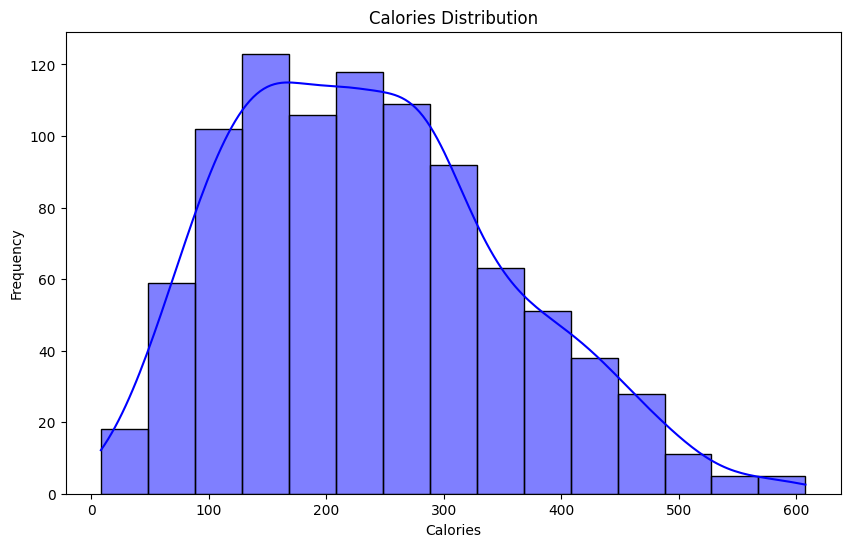

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(recipe_df['Calories'], kde=True, bins=15, color='blue')
plt.title('Calories Distribution')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

### Recipe key distribution

Here, I've used bar plot instead of histograms because we don't need bins here. We have descrete values for recipe keys and i wanted to see how many recipies belong to each key in a sorted manner.
Below is the description for keys:


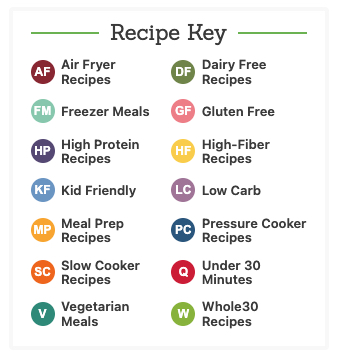

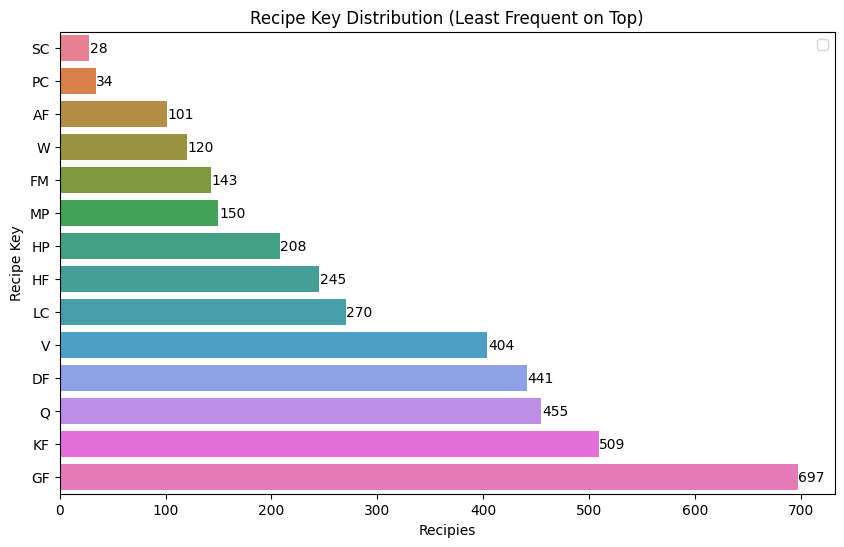

In [12]:
recipe_df['Recipe Keys Cleaned'] = recipe_df['Recipe Keys'].str.split(', ')  # Split the keys into lists
all_keys = recipe_df.explode('Recipe Keys Cleaned')['Recipe Keys Cleaned']  # Explode the lists to create one key per row

# Handle duplicate labels by grouping and counting properly
key_counts = all_keys.value_counts().reset_index()  # Count occurrences of each key
key_counts.columns = ['Recipe Key', 'Count']  # Rename columns for clarity


# Reverse the order (least frequent on top, most on bottom)
key_counts = key_counts.sort_values('Count', ascending=True)

# Plot the distribution of recipe keys
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Recipe Key', x='Count', data=key_counts, hue='Recipe Key', legend=False, order=key_counts['Recipe Key'])

# Annotate the bars with the count of each key
for index, value in enumerate(key_counts['Count']):
    ax.text(value + 0.5, index, str(value), va='center')

plt.title('Recipe Key Distribution (Least Frequent on Top)')
plt.xlabel('Recipies')
plt.ylabel('Recipe Key')

plt.legend()
plt.show()

### Personal Points Distribution
Again bar plot for distribution, as it can be seen that most of the recipies have points in between [2, 7]

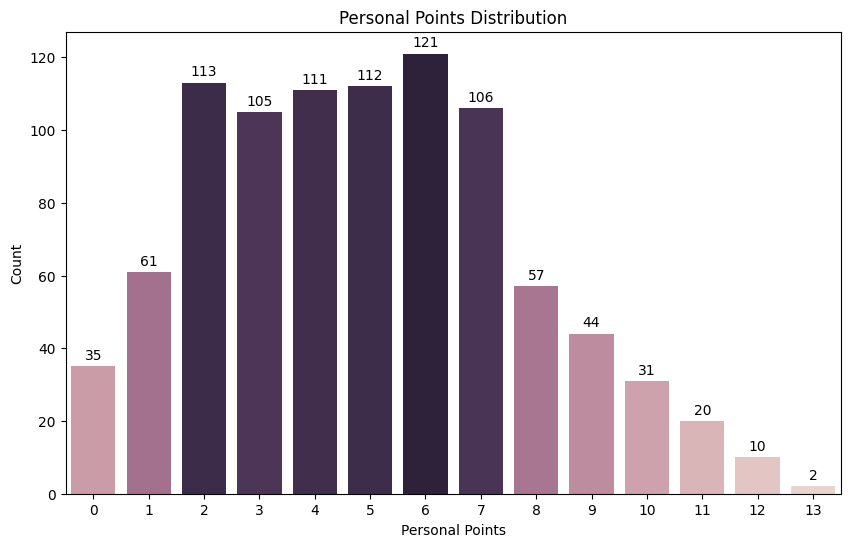

In [13]:
personal_points_counts = recipe_df['Personal Points'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=personal_points_counts.index, y=personal_points_counts.values, hue=personal_points_counts.values, legend=False)

# Title and labels
plt.title('Personal Points Distribution')
plt.xlabel('Personal Points')
plt.ylabel('Count')

# Annotate each bar with the count
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                xytext=(0, 5), textcoords='offset points')

# Show the plot
plt.show()

### User Interaction System.

In [14]:
from IPython.display import HTML

def filter_and_display_foods(recipe_df):
    while True:
        try:
            print("\n--- Please enter your desired ranges ---")
            calorie_min = input("Enter minimum calories (or type 'exit' to quit): ").strip()
            if calorie_min.lower() == 'exit':
                print("Exiting...")
                break

            calorie_max = input("Enter maximum calories: ").strip()
            if calorie_max.lower() == 'exit':
                print("Exiting...")
                break

            point_min = input("Enter minimum personal points: ").strip()
            if point_min.lower() == 'exit':
                print("Exiting...")
                break

            point_max = input("Enter maximum personal points: ").strip()
            if point_max.lower() == 'exit':
                print("Exiting...")
                break

            calorie_min = float(calorie_min)
            calorie_max = float(calorie_max)
            point_min = int(point_min)
            point_max = int(point_max)

            filtered_df = recipe_df[
                (recipe_df['Calories'].astype(float) >= calorie_min) &
                (recipe_df['Calories'].astype(float) <= calorie_max) &
                (recipe_df['Personal Points'].astype(int) >= point_min) &
                (recipe_df['Personal Points'].astype(int) <= point_max)
            ]

            # Sort by Calories and take top 10 results
            filtered_df = filtered_df.sort_values(by='Calories').head(10)

            if filtered_df.empty:
                print("\nNo results found within the specified ranges.")
            else:
                # Create a new column with HTML img tags to render images
                filtered_df['Image'] = filtered_df['Image URL'].apply(
                    lambda x: f'<img src="{x}" width="150" height="150">'
                )

                # Select and reorder columns to display the desired output
                display_df = filtered_df[['Recipe Name', 'Calories', 'Personal Points', 'Recipe Summary', 'Image']]

                # Render the DataFrame as HTML for displaying in Jupyter
                display(HTML(display_df.to_html(escape=False)))

        except ValueError:
            print("Invalid input. Please enter valid numeric values for calorie and point ranges.")

In [15]:
filter_and_display_foods(recipe_df)


--- Please enter your desired ranges ---
Enter minimum calories (or type 'exit' to quit): 1
Enter maximum calories: 1000
Enter minimum personal points: 1
Enter maximum personal points: 9


,Recipe Name,Calories,Personal Points,Recipe Summary,Image
154,Turkey Gravy,33.0,1,This homemade Turkey Gravy from stock is my mom’s tried and true recipe. It’s a staple on ourThanksgiving tableevery year.,
678,Virgin Bloody Mary,33.0,1,"Craving a Bloody Mary but doing a dry challenge? Make this Virgin Bloody Mary, also known as the Virgin Mary, and you won’t miss the vodka!",
3,Apple Butter,34.0,1,"This easy apple butter recipe simmers on the stove, made with apples, cinnamon, nutmeg, and allspice, it smells and tastes like fall!",
526,Spinach and Bacon Stuffed Mushrooms,34.5,1,"The stuffing is so good, I could eat it by the spoonful! More mushroom appetizers you might also likePhilly Cheesesteak Stuffed Mushrooms,Mushroom CevicheorLasagna Stuffed Mushrooms.",
329,Buffalo Chicken Meatballs,37.0,1,"These healthy buffalo chicken meatballs are a great option for a weeknightdinner, game day snack, or partyappetizer. Serve them with celery sticks and blue cheese dressing for dipping, or enjoy them on their own.",
866,Mango-Raspberry Fruit Roll Ups,39.0,1,"Homemade Mango-Raspberry Fruit Roll Ups, so much healthier than the store-bought kind, and with much less added sugar.",
848,Pumpkin Butter,42.0,2,"Pumpkin lovers will love this easy, pumpkin butter recipe made from scratch. It’s like pumpkin pie in a jar, only better! Delicious smeared on toast, oatmeal, yogurt, and more!",
802,Whole Roasted Baby Cauliflower,46.5,1,"This simple, Whole Roasted Baby Cauliflower is perfectly charred on the outside and tender in the middle. Made with just four ingredients – salted water, extra-virgin olive oil, coarse sea salt—and cauliflower.",
885,Perfectly Grilled Zucchini Recipe,48.0,1,"Make Perfectly Grilled Zucchini all summer long! Quick and easy, great as a side dish with anything you’re grilling.",
884,Bruschetta with Tomato and Basil,49.6,2,"Bruschetta with Tomato and Basil, one of my favorite ways to use up all my summer tomatoes is with this simpleappetizeror side dish.",



--- Please enter your desired ranges ---
Enter minimum calories (or type 'exit' to quit): exit
Exiting...
